# Анализ эффективности маркетинговых инвестиций Procrastinate Pro+

### Описание проекта

В ходе исследования была проведена оценка эффективности маркетинговых инвестиций развлекательного приложения Procrastinate Pro+.

Несмотря на значительные расходы на привлечение пользователей, компания столкнулась со снижением эффективности маркетинговых инвестиций и проблемами окупаемости рекламы. 

### Цель исследования

Определить причины низкой окупаемости маркетинговых инвестиций и выявить рекламные каналы, устройства и регионы, оказывающие наибольшее влияние на эффективность привлечения пользователей.

Для анализа использовались данные о пользователях, привлечённых в период с 1 мая по 27 октября 2019 года:

* данные о посещениях приложения;
* информация о покупках пользователей;
* данные о рекламных расходах.

В рамках исследования были проанализированы:

* структура пользовательской аудитории по странам, устройствам и каналам привлечения;
* стоимость привлечения пользователей (CAC);
* жизненная ценность клиентов (LTV);
* окупаемость маркетинговых инвестиций (ROI);
* конверсия и удержание пользователей;
* влияние рекламных каналов, устройств и регионов на эффективность привлечения клиентов.


# Подготовка данных 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
visits = pd.read_csv('visits_info_short.csv')
orders = pd.read_csv('orders_info_short.csv')
costs = pd.read_csv('costs_info_short.csv')

In [3]:
for data in [visits, orders, costs]:
    display(data.head())
    print(data.info())

,User Id,Region,Device,Channel,Session Start,Session End
0,981449118918,United States,iPhone,organic,2019-05-01 02:36:01,2019-05-01 02:45:01
1,278965908054,United States,iPhone,organic,2019-05-01 04:46:31,2019-05-01 04:47:35
2,590706206550,United States,Mac,organic,2019-05-01 14:09:25,2019-05-01 15:32:08
3,326433527971,United States,Android,TipTop,2019-05-01 00:29:59,2019-05-01 00:54:25
4,349773784594,United States,Mac,organic,2019-05-01 03:33:35,2019-05-01 03:57:40


<class 'pandas.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   User Id        309901 non-null  int64
 1   Region         309901 non-null  str  
 2   Device         309901 non-null  str  
 3   Channel        309901 non-null  str  
 4   Session Start  309901 non-null  str  
 5   Session End    309901 non-null  str  
dtypes: int64(1), str(5)
memory usage: 14.2 MB
None


,User Id,Event Dt,Revenue
0,188246423999,2019-05-01 23:09:52,4.99
1,174361394180,2019-05-01 12:24:04,4.99
2,529610067795,2019-05-01 11:34:04,4.99
3,319939546352,2019-05-01 15:34:40,4.99
4,366000285810,2019-05-01 13:59:51,4.99


<class 'pandas.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User Id   40212 non-null  int64  
 1   Event Dt  40212 non-null  str    
 2   Revenue   40212 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 942.6 KB
None


,dt,Channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8
3,2019-05-04,FaceBoom,136.4
4,2019-05-05,FaceBoom,122.1


<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   str    
 1   Channel  1800 non-null   str    
 2   costs    1800 non-null   float64
dtypes: float64(1), str(2)
memory usage: 42.3 KB
None


In [4]:
def data_preparation(data, data_columns):

    for col in data_columns:
        data[col] = pd.to_datetime(data[col])

    data.columns = data.columns.str.replace(" ", "_") \
                               .str.lower()

    return data

In [5]:
visits = data_preparation(visits, ['Session Start', 'Session End'])
orders = data_preparation(orders, ['Event Dt'])
costs = data_preparation(costs, ['dt'])

In [6]:
for data in [visits, orders, costs]:
    display(data.head())
    print(data.info())

,user_id,region,device,channel,session_start,session_end
0,981449118918,United States,iPhone,organic,2019-05-01 02:36:01,2019-05-01 02:45:01
1,278965908054,United States,iPhone,organic,2019-05-01 04:46:31,2019-05-01 04:47:35
2,590706206550,United States,Mac,organic,2019-05-01 14:09:25,2019-05-01 15:32:08
3,326433527971,United States,Android,TipTop,2019-05-01 00:29:59,2019-05-01 00:54:25
4,349773784594,United States,Mac,organic,2019-05-01 03:33:35,2019-05-01 03:57:40


<class 'pandas.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        309901 non-null  int64         
 1   region         309901 non-null  str           
 2   device         309901 non-null  str           
 3   channel        309901 non-null  str           
 4   session_start  309901 non-null  datetime64[us]
 5   session_end    309901 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(1), str(3)
memory usage: 14.2 MB
None


,user_id,event_dt,revenue
0,188246423999,2019-05-01 23:09:52,4.99
1,174361394180,2019-05-01 12:24:04,4.99
2,529610067795,2019-05-01 11:34:04,4.99
3,319939546352,2019-05-01 15:34:40,4.99
4,366000285810,2019-05-01 13:59:51,4.99


<class 'pandas.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   40212 non-null  int64         
 1   event_dt  40212 non-null  datetime64[us]
 2   revenue   40212 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 942.6 KB
None


,dt,channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8
3,2019-05-04,FaceBoom,136.4
4,2019-05-05,FaceBoom,122.1


<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   dt       1800 non-null   datetime64[us]
 1   channel  1800 non-null   str           
 2   costs    1800 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 42.3 KB
None


In [7]:
for data in [visits, orders, costs]:
    print(data.isna().sum())
    print(data.duplicated().sum())
    print()

user_id          0
region           0
device           0
channel          0
session_start    0
session_end      0
dtype: int64
0

user_id     0
event_dt    0
revenue     0
dtype: int64
0

dt         0
channel    0
costs      0
dtype: int64
0



В ходе предобработки данные были проверены на пропуски и дубликаты. Пропущенные значения и явные дубликаты не обнаружены. Столбцы с датой и временем были приведены к типу datetime, названия колонок переведены в удобный для анализа формат.

## Методология расчёта метрик

Для расчёта ключевых маркетинговых метрик были подготовлены функции для построения профилей пользователей, расчёта LTV, ROI, CAC, конверсии и удержания, а также визуализации результатов анализа.


Функции для вычисления значений метрик: 
- get_profiles() — для создания профилей пользователей,
- get_retention() — для подсчёта Retention Rate,
- get_conversion() — для подсчёта конверсии,
- get_ltv() — для подсчёта LTV.

Функции для построения графиков:
- filter_data() — для сглаживания данных,
- plot_retention() — для построения графика Retention Rate,
- plot_conversion() — для построения графика конверсии,
- plot_ltv_roi — для визуализации LTV и ROI.

In [8]:
# функция для создания пользовательских профилей

def get_profiles(sessions, orders, ad_costs):

    # находим параметры первых посещений
    profiles = (
        sessions.sort_values(by=['user_id', 'session_start'])
        .groupby('user_id')
        .agg(
            {
                'session_start': 'first',
                'channel': 'first',
                'device': 'first',
                'region': 'first',
            }
        )
        .rename(columns={'session_start': 'first_ts'})
        .reset_index()
    )

    # для когортного анализа определяем дату первого посещения
    # и первый день месяца, в который это посещение произошло
    profiles['dt'] = profiles['first_ts'].dt.normalize()
    profiles['month'] = profiles['first_ts'].values.astype('datetime64[M]')

    # добавляем признак платящих пользователей
    profiles['payer'] = profiles['user_id'].isin(orders['user_id'].unique())

    # считаем количество уникальных пользователей
    # с одинаковыми источником и датой привлечения
    new_users = (
        profiles.groupby(['dt', 'channel'])
        .agg({'user_id': 'nunique'})
        .rename(columns={'user_id': 'unique_users'})
        .reset_index()
    )

    # объединяем траты на рекламу и число привлечённых пользователей
    ad_costs = ad_costs.merge(new_users, on=['dt', 'channel'], how='left')

    # делим рекламные расходы на число привлечённых пользователей
    ad_costs['acquisition_cost'] = ad_costs['costs'] / ad_costs['unique_users']

    # добавляем стоимость привлечения в профили
    profiles = profiles.merge(
        ad_costs[['dt', 'channel', 'acquisition_cost']],
        on=['dt', 'channel'],
        how='left',
    )

    # стоимость привлечения органических пользователей равна нулю
    profiles['acquisition_cost'] = profiles['acquisition_cost'].fillna(0)

    return profiles


In [9]:
# функция для расчёта удержания

def get_retention(
    profiles,
    sessions,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # добавляем столбец payer в передаваемый dimensions список
    dimensions = ['payer'] + dimensions

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # собираем «сырые» данные для расчёта удержания
    result_raw = result_raw.merge(
        sessions[['user_id', 'session_start']], on='user_id', how='left'
    )
    result_raw['lifetime'] = (
        result_raw['session_start'] - result_raw['first_ts']
    ).dt.days

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу удержания
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # получаем таблицу динамики удержания
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

In [10]:

# функция для расчёта конверсии

def get_conversion(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # определяем дату и время первой покупки для каждого пользователя
    first_purchases = (
        purchases.sort_values(by=['user_id', 'event_dt'])
        .groupby('user_id')
        .agg({'event_dt': 'first'})
        .reset_index()
    )

    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        first_purchases[['user_id', 'event_dt']], on='user_id', how='left'
    )

    # рассчитываем лайфтайм для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days

    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users' 
        dimensions = dimensions + ['cohort']

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        result = result.fillna(0).cumsum(axis = 1)
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # делим каждую «ячейку» в строке на размер когорты
        # и получаем conversion rate
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу конверсии
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # для таблицы динамики конверсии убираем 'cohort' из dimensions
    if 'cohort' in dimensions: 
        dimensions = []

    # получаем таблицу динамики конверсии
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

In [11]:
# функция для расчёта LTV и ROI

def get_ltv(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')
    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        purchases[['user_id', 'event_dt', 'revenue']], on='user_id', how='left'
    )
    # рассчитываем лайфтайм пользователя для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days
    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # функция группировки по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        # строим «треугольную» таблицу выручки
        result = df.pivot_table(
            index=dims, columns='lifetime', values='revenue', aggfunc='sum'
        )
        # находим сумму выручки с накоплением
        result = result.fillna(0).cumsum(axis=1)
        # вычисляем размеры когорт
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        # объединяем размеры когорт и таблицу выручки
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # считаем LTV: делим каждую «ячейку» в строке на размер когорты
        result = result.div(result['cohort_size'], axis=0)
        # исключаем все лайфтаймы, превышающие горизонт анализа
        result = result[['cohort_size'] + list(range(horizon_days))]
        # восстанавливаем размеры когорт
        result['cohort_size'] = cohort_sizes

        # собираем датафрейм с данными пользователей и значениями CAC, 
        # добавляя параметры из dimensions
        cac = df[['user_id', 'acquisition_cost'] + dims].drop_duplicates()

        # считаем средний CAC по параметрам из dimensions
        cac = (
            cac.groupby(dims)
            .agg({'acquisition_cost': 'mean'})
            .rename(columns={'acquisition_cost': 'cac'})
        )

        # считаем ROI: делим LTV на CAC
        roi = result.div(cac['cac'], axis=0)

        # удаляем строки с бесконечным ROI
        roi = roi[~roi['cohort_size'].isin([np.inf])]

        # восстанавливаем размеры когорт в таблице ROI
        roi['cohort_size'] = cohort_sizes

        # добавляем CAC в таблицу ROI
        roi['cac'] = cac['cac']

        # в финальной таблице оставляем размеры когорт, CAC
        # и ROI в лайфтаймы, не превышающие горизонт анализа
        roi = roi[['cohort_size', 'cac'] + list(range(horizon_days))]

        # возвращаем таблицы LTV и ROI
        return result, roi

    # получаем таблицы LTV и ROI
    result_grouped, roi_grouped = group_by_dimensions(
        result_raw, dimensions, horizon_days
    )

    # для таблиц динамики убираем 'cohort' из dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # получаем таблицы динамики LTV и ROI
    result_in_time, roi_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    return (
        result_raw,  # сырые данные
        result_grouped,  # таблица LTV
        result_in_time,  # таблица динамики LTV
        roi_grouped,  # таблица ROI
        roi_in_time,  # таблица динамики ROI
    )

In [12]:
# функция для сглаживания фрейма

def filter_data(df, window):
    # для каждого столбца применяем скользящее среднее
    for column in df.columns.values:
        df[column] = df[column].rolling(window).mean() 
    return df

In [13]:
# функция для визуализации удержания

def plot_retention(retention, retention_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 10))

    # исключаем размеры когорт и удержание первого дня
    retention = retention.drop(columns=['cohort_size', 0])
    # в таблице динамики оставляем только нужный лайфтайм
    retention_history = retention_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # если в индексах таблицы удержания только payer,
    # добавляем второй признак — cohort
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users'
        retention = retention.reset_index().set_index(['cohort', 'payer'])

    # в таблице графиков — два столбца и две строки, четыре ячейки
    # в первой строим кривые удержания платящих пользователей
    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(
        grid=True, ax=ax1
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание платящих пользователей')

    # во второй ячейке строим кривые удержания неплатящих
    # вертикальная ось — от графика из первой ячейки
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    retention.query('payer == False').droplevel('payer').T.plot(
        grid=True, ax=ax2
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание неплатящих пользователей')

    # в третьей ячейке — динамика удержания платящих
    ax3 = plt.subplot(2, 2, 3)
    # получаем названия столбцов для сводной таблицы
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']
    ]
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания платящих пользователей на {}-й день'.format(
            horizon
        )
    )

    # в чётвертой ячейке — динамика удержания неплатящих
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == False').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax4)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания неплатящих пользователей на {}-й день'.format(
            horizon
        )
    )
    
    plt.tight_layout()
    plt.show()

In [14]:
# функция для визуализации конверсии

def plot_conversion(conversion, conversion_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 5))

    # исключаем размеры когорт
    conversion = conversion.drop(columns=['cohort_size'])
    # в таблице динамики оставляем только нужный лайфтайм
    conversion_history = conversion_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # первый график — кривые конверсии
    ax1 = plt.subplot(1, 2, 1)
    conversion.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Конверсия пользователей')

    # второй график — динамика конверсии
    ax2 = plt.subplot(1, 2, 2, sharey=ax1)
    columns = [
        # столбцами сводной таблицы станут все столбцы индекса, кроме даты
        name for name in conversion_history.index.names if name not in ['dt']
    ]
    filtered_data = conversion_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика конверсии пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show()

In [15]:
# функция для визуализации LTV и ROI

def plot_ltv_roi(ltv, ltv_history, roi, roi_history, horizon, window=7):

    # задаём сетку отрисовки графиков
    plt.figure(figsize=(20, 10))

    # из таблицы ltv исключаем размеры когорт
    ltv = ltv.drop(columns=['cohort_size'])
    # в таблице динамики ltv оставляем только нужный лайфтайм
    ltv_history = ltv_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # стоимость привлечения запишем в отдельный фрейм
    cac_history = roi_history[['cac']]

    # из таблицы roi исключаем размеры когорт и cac
    roi = roi.drop(columns=['cohort_size', 'cac'])
    # в таблице динамики roi оставляем только нужный лайфтайм
    roi_history = roi_history.drop(columns=['cohort_size', 'cac'])[
        [horizon - 1]
    ]

    # первый график — кривые ltv
    ax1 = plt.subplot(2, 3, 1)
    ltv.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('LTV')

    # второй график — динамика ltv
    ax2 = plt.subplot(2, 3, 2, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in ltv_history.index.names if name not in ['dt']]
    filtered_data = ltv_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика LTV пользователей на {}-й день'.format(horizon))

    # третий график — динамика cac
    ax3 = plt.subplot(2, 3, 3, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in cac_history.index.names if name not in ['dt']]
    filtered_data = cac_history.pivot_table(
        index='dt', columns=columns, values='cac', aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика стоимости привлечения пользователей')

    # четвёртый график — кривые roi
    ax4 = plt.subplot(2, 3, 4)
    roi.T.plot(grid=True, ax=ax4)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('ROI')

    # пятый график — динамика roi
    ax5 = plt.subplot(2, 3, 5, sharey=ax4)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in roi_history.index.names if name not in ['dt']]
    filtered_data = roi_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax5)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.xlabel('Дата привлечения')
    plt.title('Динамика ROI пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show()

# Исследовательский анализ данных

#### Анализ профилей пользователей и периода привлечения

In [16]:
profiles = get_profiles(visits, orders, costs)
profiles.head()

,user_id,first_ts,channel,device,region,dt,month,payer,acquisition_cost
0,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,2019-05-01,True,1.088172
1,4919697,2019-07-09 12:46:07,FaceBoom,iPhone,United States,2019-07-09,2019-07-01,False,1.107237
2,6085896,2019-10-01 09:58:33,organic,iPhone,France,2019-10-01,2019-10-01,False,0.000000
3,22593348,2019-08-22 21:35:48,AdNonSense,PC,Germany,2019-08-22,2019-08-01,False,0.988235
4,31989216,2019-10-02 00:07:44,YRabbit,iPhone,United States,2019-10-02,2019-10-01,False,0.230769


In [17]:
print('Минимальная дата привлечения пользователей: {}'.format(profiles['dt'].min()))
print('Максимальная дата привлечения пользователей: {}'.format(profiles['dt'].max()))

Минимальная дата привлечения пользователей: 2019-05-01 00:00:00
Максимальная дата привлечения пользователей: 2019-10-27 00:00:00


Данные содержат информацию о пользователях, привлечённых в период с 1 мая по 27 октября 2019 года.

#### Анализ пользовательской аудитории по странам

In [18]:
region_df = profiles.groupby('region')['user_id'].count().reset_index().merge(
    profiles.query('payer == True').groupby('region')['user_id'].count().reset_index(), on='region')

region_df.columns = ['country', 'cnt_users', 'cnt_payers']
region_df['payers_share'] = round(region_df['cnt_payers'] / region_df['cnt_users'] * 100, 2)

region_df.sort_values(by='payers_share', ascending=False)

,country,cnt_users,cnt_payers,payers_share
3,United States,100002,6902,6.90
1,Germany,14981,616,4.11
2,UK,17575,700,3.98
0,France,17450,663,3.80


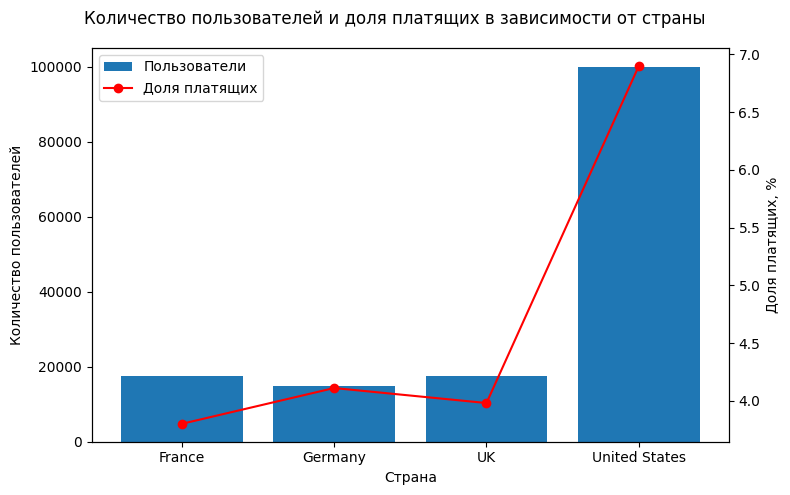

In [19]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(region_df['country'], region_df['cnt_users'], label='Пользователи')
ax1.set_ylabel('Количество пользователей')
ax1.set_xlabel('Страна')

ax2 = ax1.twinx()
ax2.plot(region_df['country'], region_df['payers_share'], marker='o', color='red', label='Доля платящих')
ax2.set_ylabel('Доля платящих, %')

# объединённая легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.suptitle('Количество пользователей и доля платящих в зависимости от страны')
plt.tight_layout()
plt.show()


Основным рынком приложения являются США: на эту страну приходится наибольшее количество пользователей и платящих клиентов. Доля платящих пользователей в США составляет около 7%, что заметно выше показателей европейских стран (около 4%). Это свидетельствует о более высокой доле платящих пользователей среди американской аудитории и подтверждает важность рынка США для бизнеса.

#### Анализ аудитории по типам устройств

In [20]:
device_df = profiles.groupby('device')['user_id'].count().reset_index().merge(
    profiles.query('payer == True').groupby('device')['user_id'].count().reset_index(), on='device')

device_df.columns = ['device', 'cnt_users', 'cnt_payers']
device_df['payers_share'] = round(device_df['cnt_payers'] / device_df['cnt_users'] * 100, 2)

device_df.sort_values(by='payers_share', ascending=False)

,device,cnt_users,cnt_payers,payers_share
1,Mac,30042,1912,6.36
3,iPhone,54479,3382,6.21
0,Android,35032,2050,5.85
2,PC,30455,1537,5.05


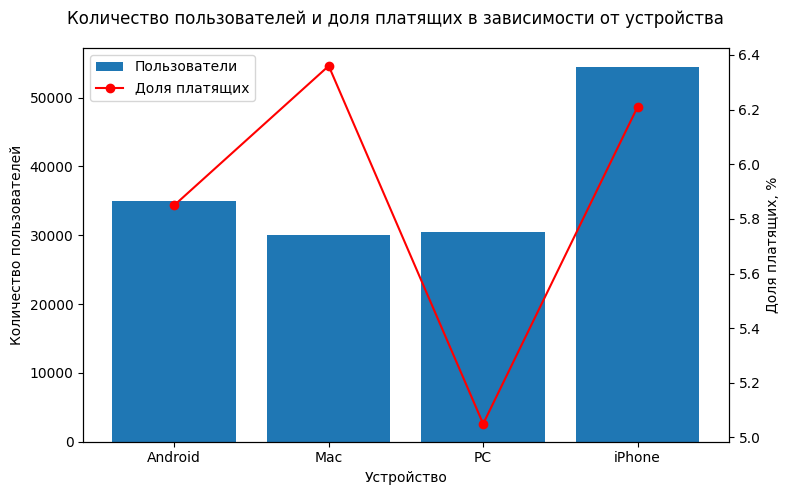

In [21]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(device_df['device'], device_df['cnt_users'], label='Пользователи')
ax1.set_ylabel('Количество пользователей')
ax1.set_xlabel('Устройство')

ax2 = ax1.twinx()
ax2.plot(device_df['device'], device_df['payers_share'], marker='o', color='red', label='Доля платящих')
ax2.set_ylabel('Доля платящих, %')

# объединённая легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.suptitle('Количество пользователей и доля платящих в зависимости от устройства')
plt.tight_layout()
plt.show()

Наиболее популярными устройствами являются iPhone и Android. Самую высокую долю платящих пользователей демонстрируют владельцы Mac. В целом, среди пользователей устройств Apple наблюдается более высокая доля платящих клиентов по сравнению с Android и PC.



#### Анализ рекламных каналов привлечения

In [22]:
channel_df = profiles.groupby('channel')['user_id'].count().reset_index().merge(
    profiles.query('payer == True').groupby('channel')['user_id'].count().reset_index(), on='channel')

channel_df.columns = ['channel', 'cnt_users', 'cnt_payers']
channel_df['payers_share'] = round(channel_df['cnt_payers'] / channel_df['cnt_users'] * 100, 2)

channel_df.sort_values(by='payers_share', ascending=False)

,channel,cnt_users,cnt_payers,payers_share
1,FaceBoom,29144,3557,12.20
0,AdNonSense,3880,440,11.34
9,lambdaMediaAds,2149,225,10.47
6,TipTop,19561,1878,9.60
5,RocketSuperAds,4448,352,7.91
7,WahooNetBanner,8553,453,5.30
8,YRabbit,4312,165,3.83
3,MediaTornado,4364,156,3.57
2,LeapBob,8553,262,3.06
4,OppleCreativeMedia,8605,233,2.71


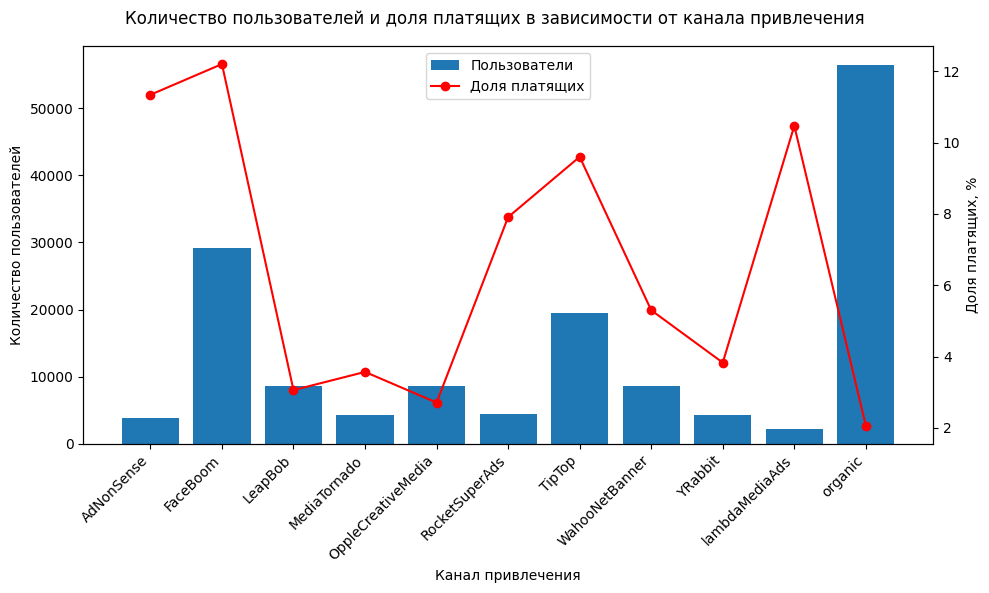

In [23]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(channel_df['channel'], channel_df['cnt_users'], label='Пользователи')
ax1.set_ylabel('Количество пользователей')
ax1.set_xlabel('Канал привлечения')
plt.xticks(rotation=45, ha='right')


ax2 = ax1.twinx()
ax2.plot(channel_df['channel'], channel_df['payers_share'], marker='o', color='red', label='Доля платящих')
ax2.set_ylabel('Доля платящих, %')

# объединённая легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center')

plt.suptitle('Количество пользователей и доля платящих в зависимости от канала привлечения')
plt.tight_layout()

Несмотря на большое количество пользователей, пришедших органически, доля платящих среди них значительно ниже, чем у большинства рекламных источников.

Среди платных источников наибольшее количество пользователей привлекают рекламные источники FaceBoom и TipTop, 29 и 19 тыс. клиентов соответственно. Из них платящими пользователями становятся от 10 до 12%. Похожие показатели по доле платящих клиентов у рекламных каналов AdNonSense и lambdaMediaAds.

Мы посмотрели на базовые значения конверсии пользователей в покупатели по регионам, устройствам и каналу привлечения, определили основной рынок. Больше всего приходит пользователей из США и они лучше других конвертируется. При этом большая часть пользователей заходит с мобильных устройств. Наибольшую конверсию имеют пользователи, которые пользуются Mac, а затем следуют пользователи iPhone. 

Пользователи устройств Apple демонстрируют более высокую долю платящих клиентов. Для подтверждения причин такого поведения требуется дополнительное исследование аудитории и её платежных привычек.

# Анализ маркетинговых расходов

#### Общий объём маркетинговых расходов

In [24]:
print('Общая сумма расходов на маркетинг', round(costs['costs'].sum(), 2))

Общая сумма расходов на маркетинг 105497.3


#### Структура маркетинговых расходов по каналам привлечения

In [25]:
df_costs = costs.groupby('channel')['costs'].sum().sort_values(ascending=False).reset_index()
df_costs

,channel,costs
0,TipTop,54751.30
1,FaceBoom,32445.60
2,WahooNetBanner,5151.00
3,AdNonSense,3911.25
4,OppleCreativeMedia,2151.25
5,RocketSuperAds,1833.00
6,LeapBob,1797.60
7,lambdaMediaAds,1557.60
8,MediaTornado,954.48
9,YRabbit,944.22


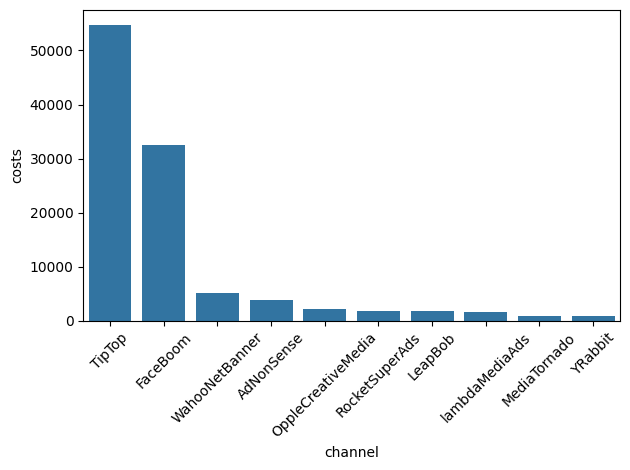

In [26]:
sns.barplot(data=df_costs, x='channel', y='costs')

plt.xticks(rotation=45)
plt.tight_layout()

Наибольшая часть рекламного бюджета приходится на каналы TipTop и FaceBoom. Расходы на них существенно превышают затраты на остальные источники, что делает их ключевыми драйверами маркетинговых затрат компании.

#### Динамика маркетинговых расходов

In [27]:
costs['week'] = costs['dt'].dt.isocalendar().week
costs['month'] = costs['dt'].dt.month
costs.head()

,dt,channel,costs,week,month
0,2019-05-01,FaceBoom,113.3,18,5
1,2019-05-02,FaceBoom,78.1,18,5
2,2019-05-03,FaceBoom,85.8,18,5
3,2019-05-04,FaceBoom,136.4,18,5
4,2019-05-05,FaceBoom,122.1,18,5


In [28]:
week_costs = costs.groupby(['week', 'channel'])['costs'].sum().reset_index()
month_costs = costs.groupby(['month', 'channel'])['costs'].sum().reset_index()

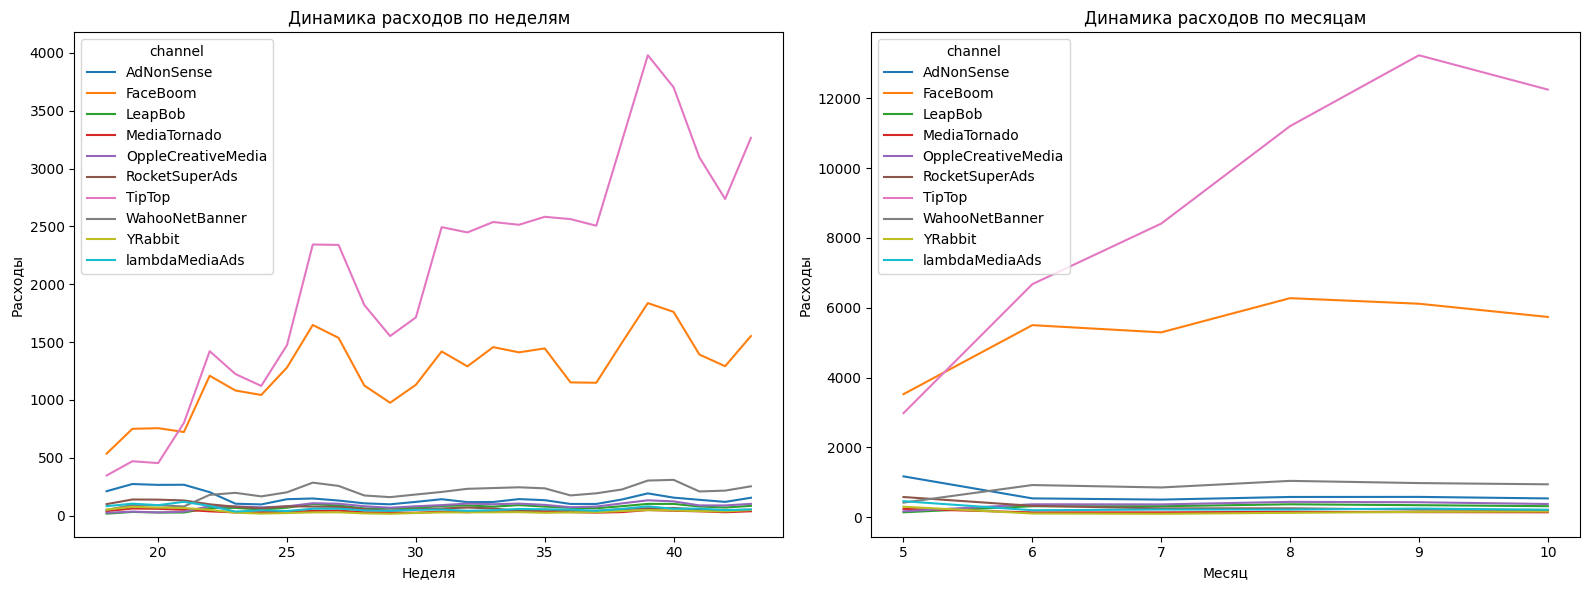

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=week_costs, x='week', y='costs', errorbar=None, hue='channel', ax=axes[0])
axes[0].set_xlabel('Неделя')
axes[0].set_ylabel('Расходы')
axes[0].set_title('Динамика расходов по неделям')

sns.lineplot(data=month_costs, x='month', y='costs', errorbar=None, hue='channel', ax=axes[1])
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Расходы')
axes[1].set_title('Динамика расходов по месяцам')

plt.tight_layout()

Самыми быстрыми темпами росли расходы на канал TipTop и в сентябре достигли 13 тыс.ед. Траты на привлечение посетителей через FaceBoom повышались постепенно, медленнее. 

Расходы для остальных рекламных источников сильнее всего менялись в первые три месяца, а затем устанавливались примерно на одном уровне. На графике видно, что по сравнению с маем траты на привлечение через канал AdNonSense упали в 2 раза, а для WahooNetBanner наоборот в несколько раз увеличились. 

#### Анализ стоимости привлечения пользователей (CAC)

In [30]:
cac = (profiles.groupby('channel')
    .agg({'acquisition_cost': 'mean'}).reset_index()
    .rename(columns={'acquisition_cost': 'cac'})
    .sort_values(by='cac', ascending=False))

cac

,channel,cac
6,TipTop,2.799003
1,FaceBoom,1.113286
0,AdNonSense,1.008054
9,lambdaMediaAds,0.724802
7,WahooNetBanner,0.602245
5,RocketSuperAds,0.412095
4,OppleCreativeMedia,0.250000
8,YRabbit,0.218975
3,MediaTornado,0.218717
2,LeapBob,0.210172


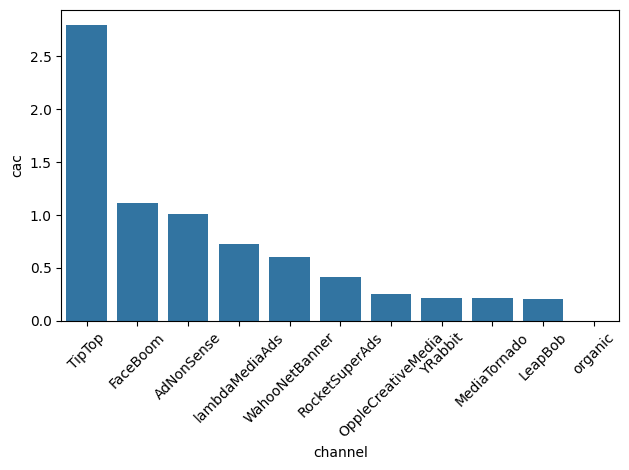

In [31]:
sns.barplot(data=cac, x='channel', y='cac')

plt.xticks(rotation=45)
plt.tight_layout()

Cредняя стоимость привлечения пользователя для рекламного источника TipTop в 2.5 раза выше по сравнению с другими каналами. 

Несмотря на самый высокий CAC, канал TipTop не демонстрирует пропорционально высокой доли платящих пользователей. Это может свидетельствовать о снижении эффективности закупки трафика или о привлечении аудитории более низкого качества.

# Анализ окупаемости рекламы

In [32]:
observation_date = datetime(2019, 11, 1).date()
horizon_days = 14

In [33]:
profiles_not_organic = profiles.query('channel != "organic"')

#### Общая оценка окупаемости маркетинговых инвестиций

In [34]:
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(profiles_not_organic, orders, observation_date, horizon_days)

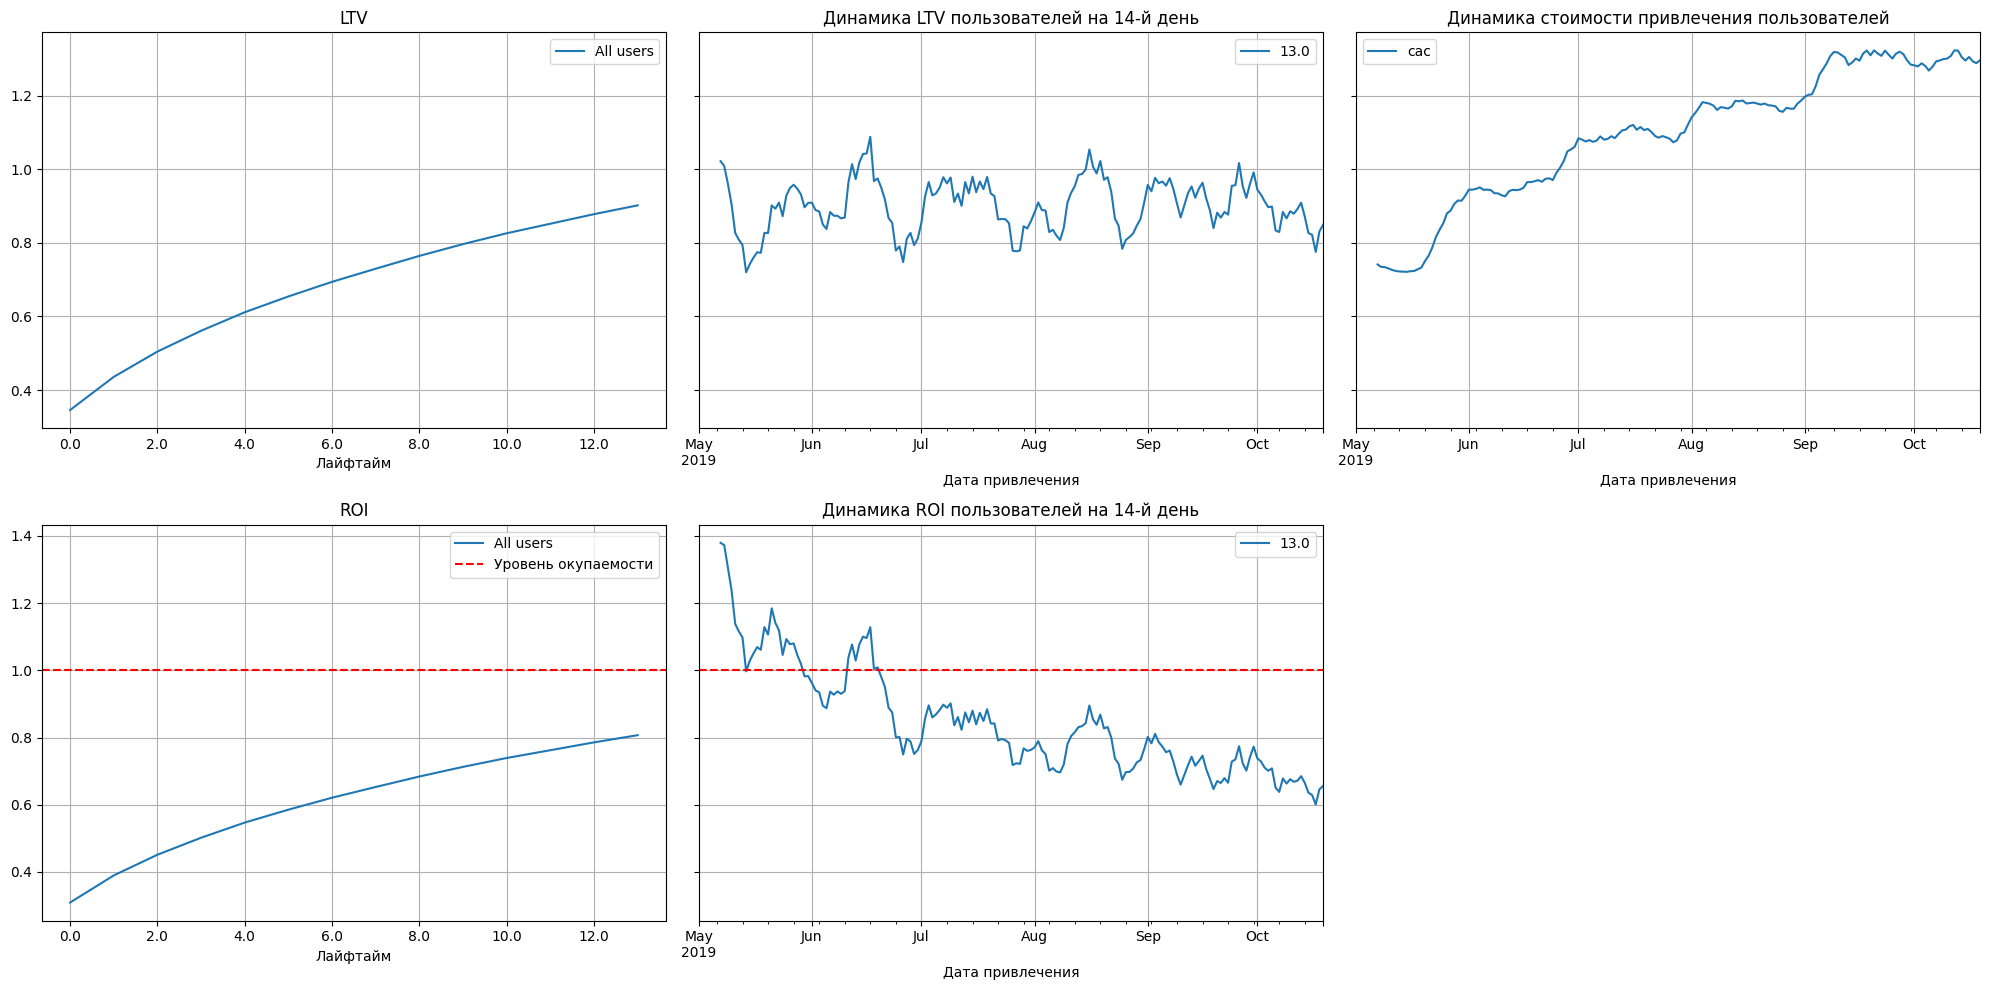

In [35]:
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

На конец анализируемого периода реклама в целом не окупается: показатель ROI составляет около 81%, что ниже порога безубыточности. При относительно стабильном LTV наблюдается устойчивый рост CAC, из-за чего эффективность маркетинговых инвестиций снижается. Основная причина ухудшения окупаемости связана именно с удорожанием привлечения пользователей.

#### Анализ конверсии и удержания пользователей

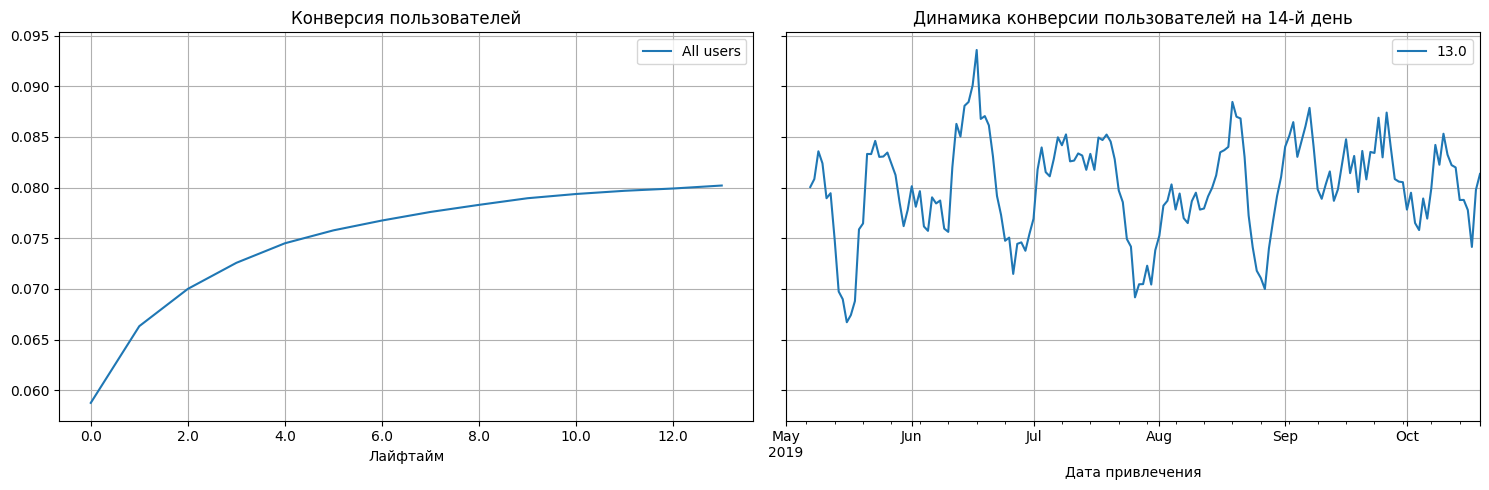

In [36]:
conversion_raw, conversion_grouped, conversion_history = get_conversion(profiles_not_organic, orders, observation_date, horizon_days)
plot_conversion(conversion_grouped, conversion_history, horizon_days)

К 14 дню после привлечения конверсия пользователей в покупателей составляет около 8%.

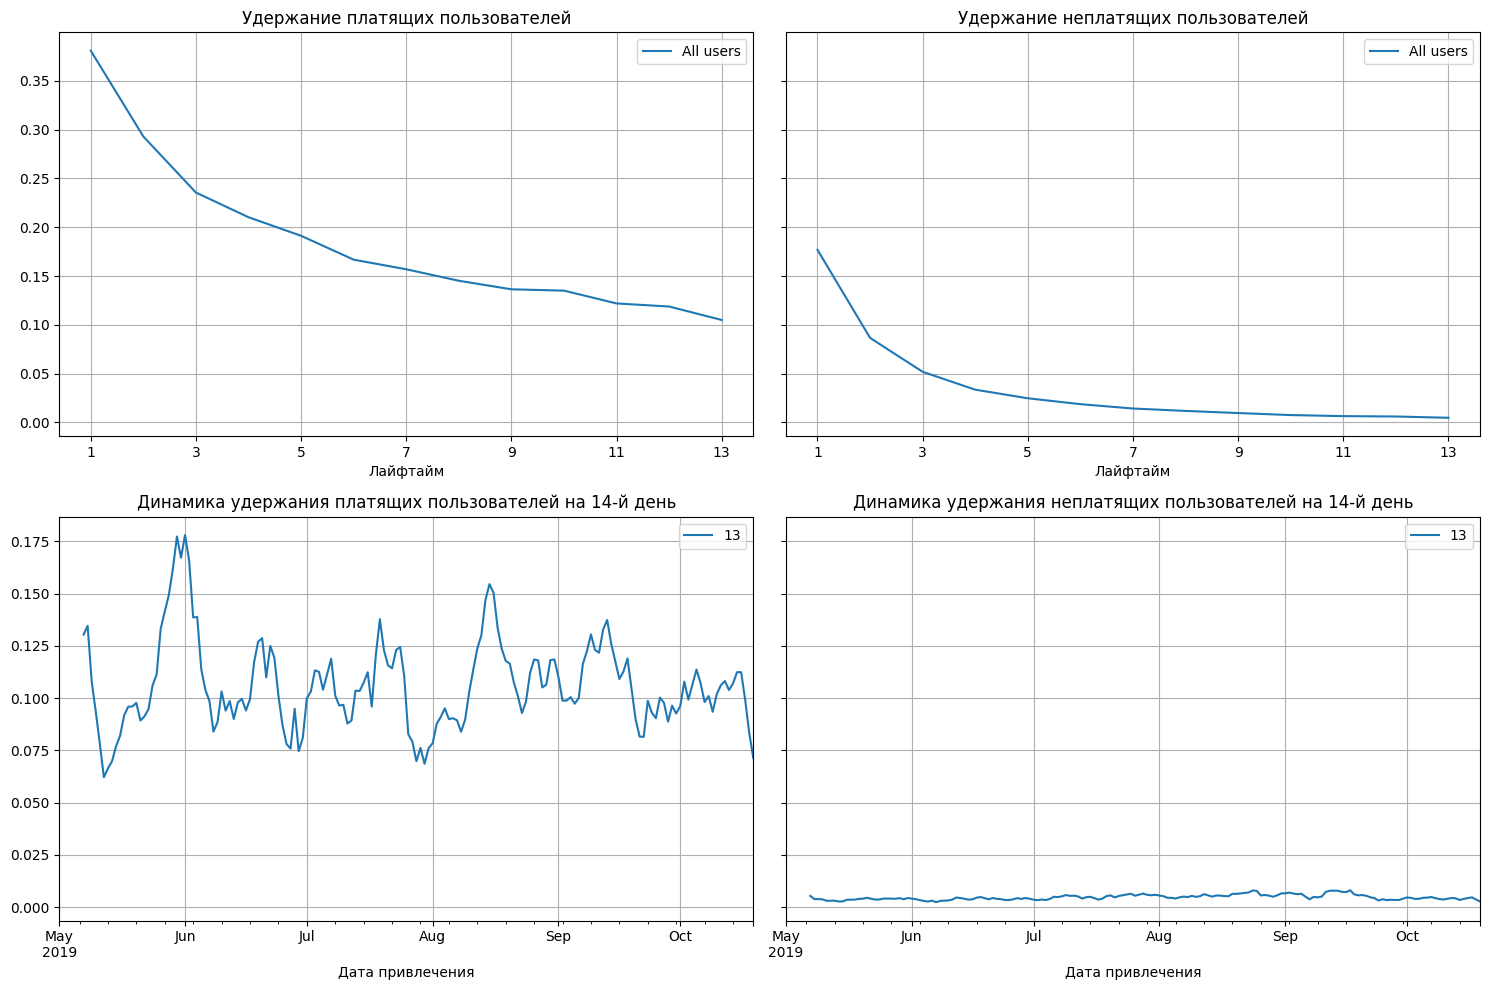

In [37]:
retention_raw, retention_grouped, retention_history = get_retention(profiles_not_organic, visits, observation_date, horizon_days)
plot_retention(retention_grouped, retention_history, horizon_days)

##### Конверсия и удержание по устройствам

In [38]:
dimensions = ['device']

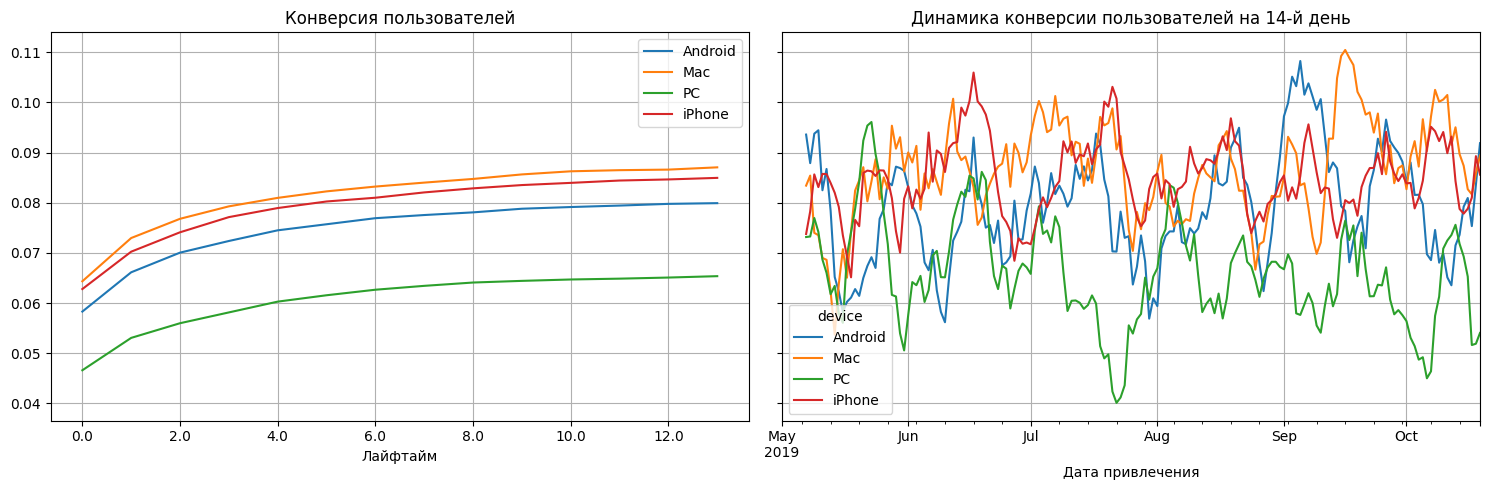

In [39]:
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles_not_organic, orders, observation_date, horizon_days, dimensions=dimensions)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

Чаще пользователи совершают первую покупку с устройств Mac и iPhone. Конверсия у поклонников PC наименьшая — 6.5%. 

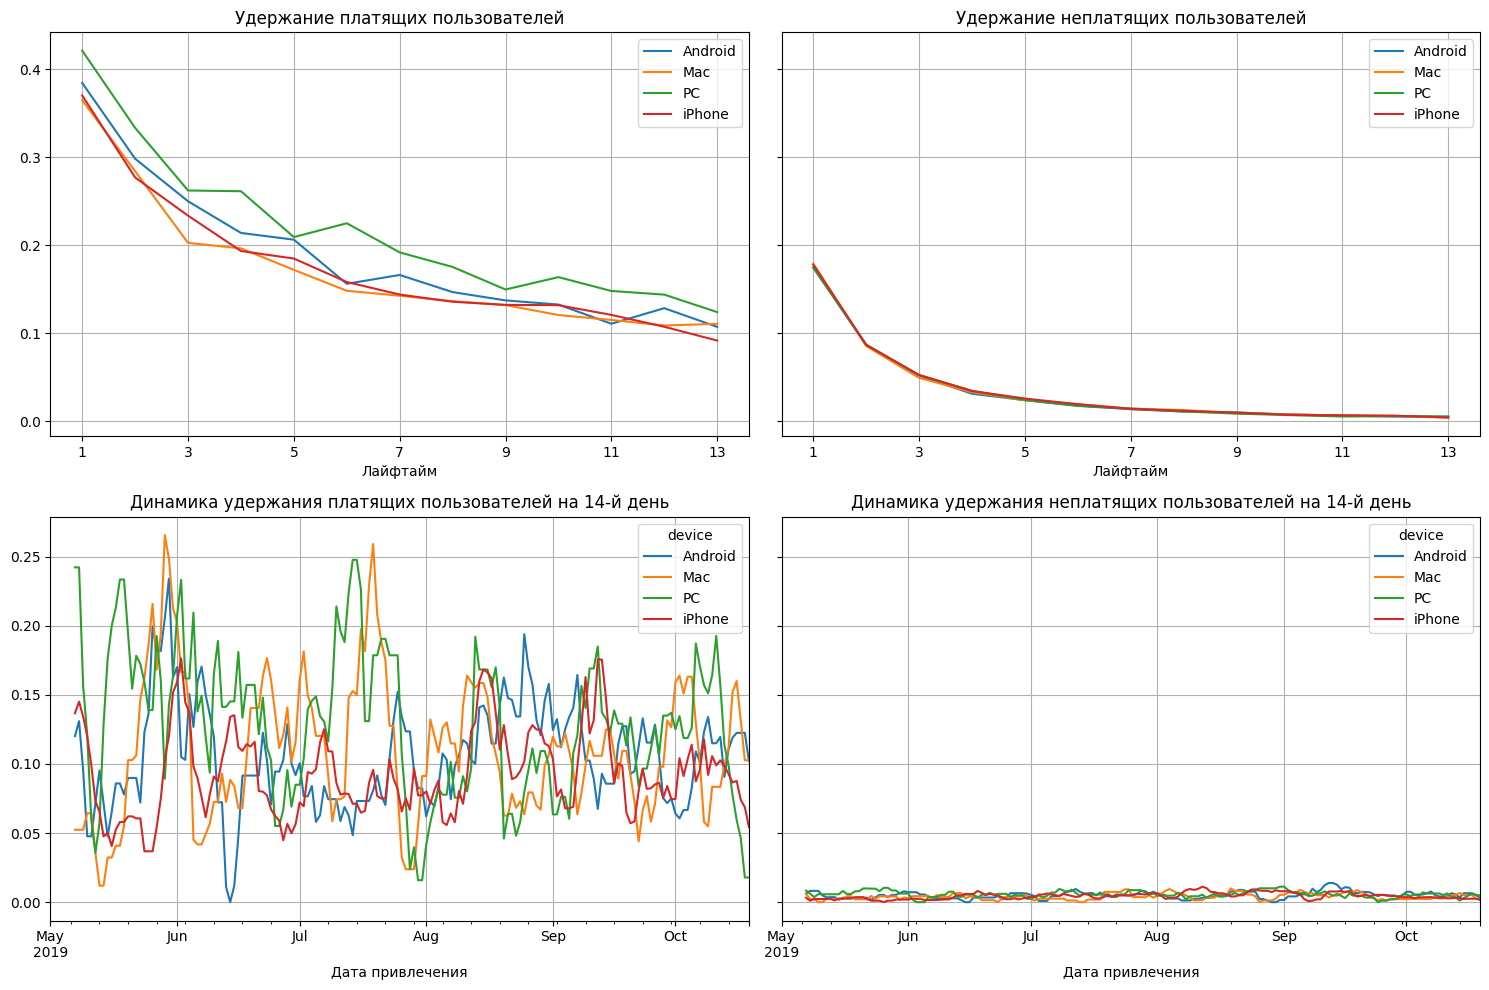

In [40]:
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_not_organic, visits, observation_date, horizon_days, dimensions=dimensions)

plot_retention(retention_grouped, retention_history, horizon_days)

Явного разрыва в удержании по устройствам на графике не видно. Наиболее высокий показатель удержания наблюдается у пользователей PC и составляет около 13%.

##### Конверсия и удержание по странам

In [41]:
dimensions = ['region']

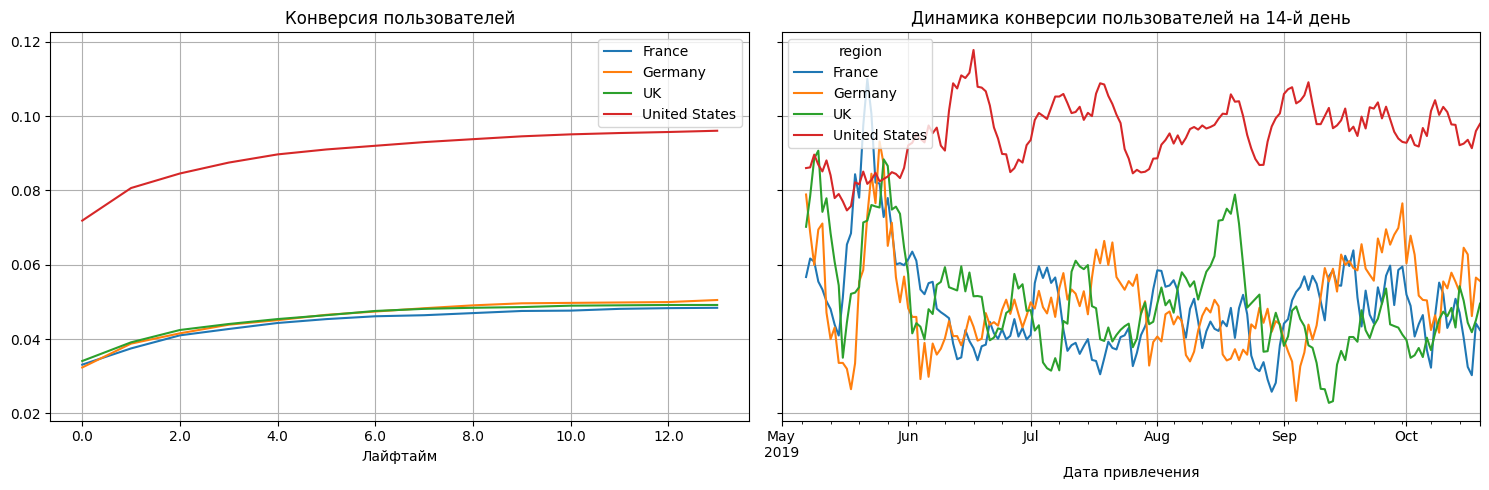

In [42]:
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles_not_organic, orders, observation_date, horizon_days, dimensions=dimensions)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

Показатель конверсии у США 9.5% в два раза превышает уровень конверсии в странах Европейского региона. Примечательно, что для европейских когорт, привлечённых в мае, конверсия также была поначалу достаточно высокой.

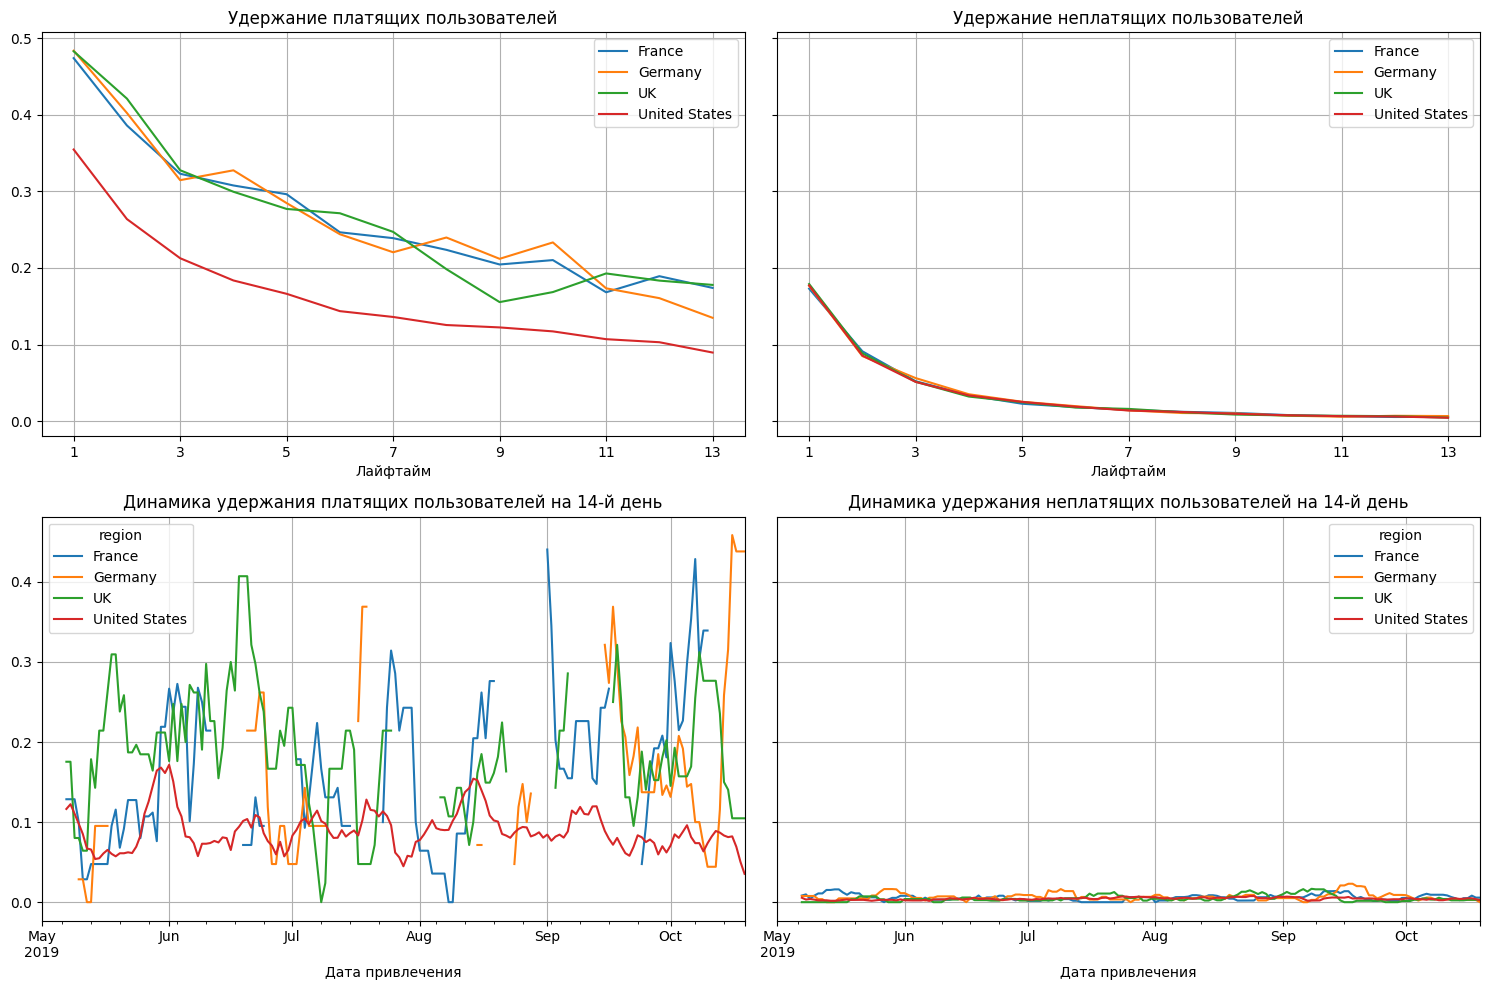

In [43]:
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_not_organic, visits, observation_date, horizon_days, dimensions=dimensions)

plot_retention(retention_grouped, retention_history, horizon_days)

Несмотря на высокую конверсию, США уступают европейским странам по удержанию. На 14 день пользоваться приложением продолжают только 10% клиентов.

##### Конверсия и удержание по каналам привлечения

In [44]:
dimensions = ['channel']

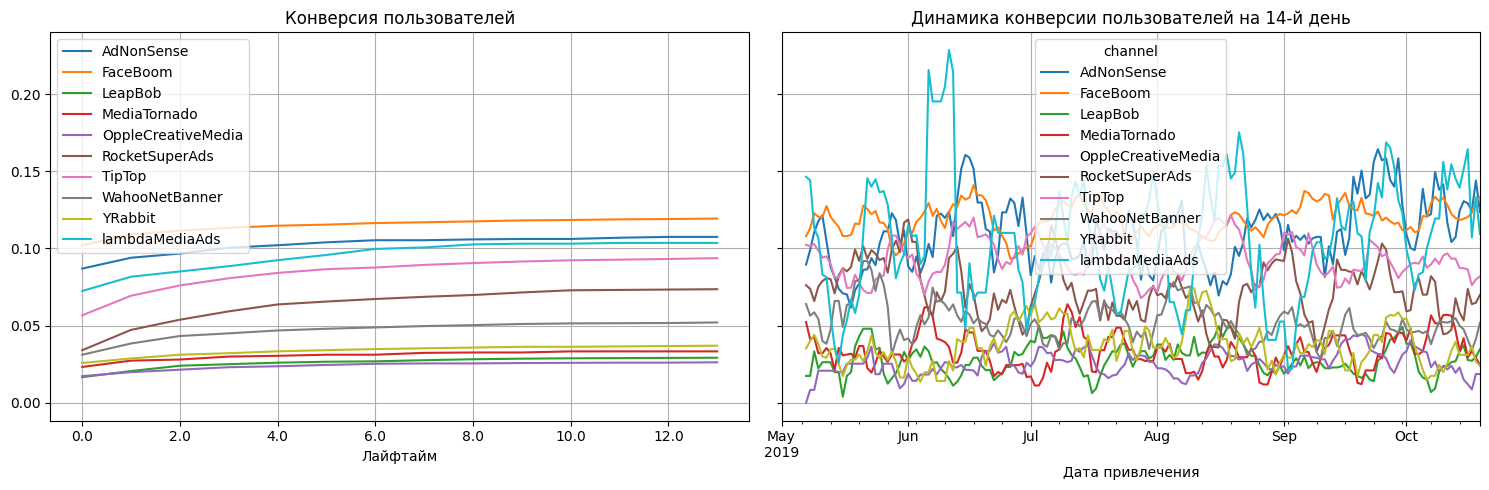

In [45]:
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles_not_organic, orders, observation_date, horizon_days, dimensions=dimensions)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

Наиболее высокую конверсию демонстрируют каналы AdNonSense, FaceBoom и lambdaMediaAds.

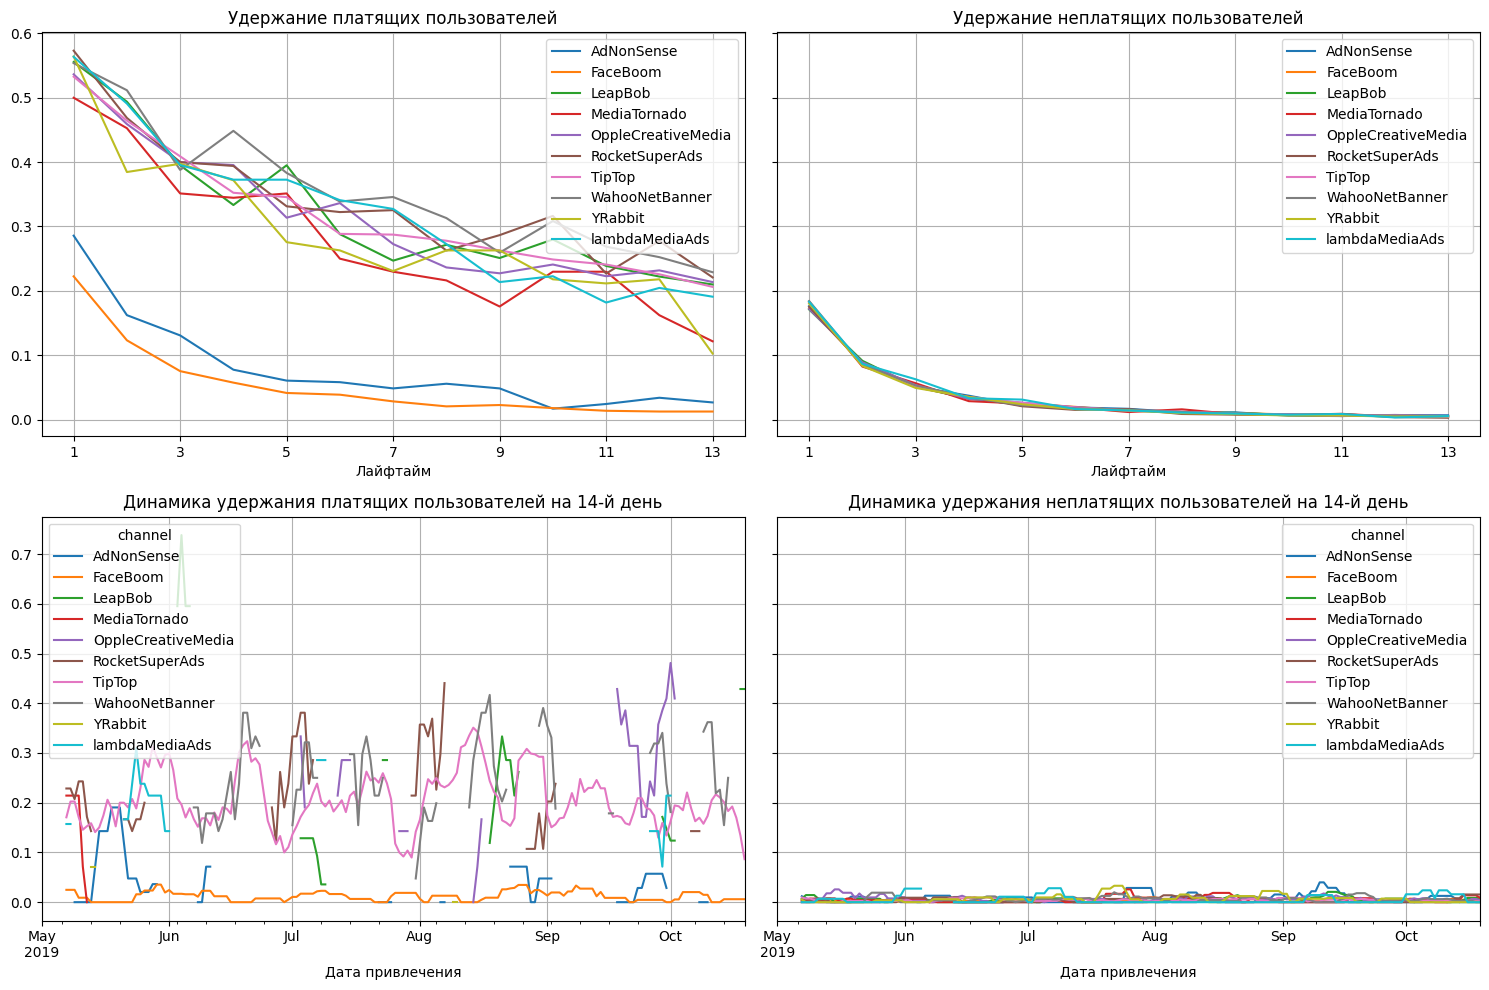

In [46]:
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_not_organic, visits, observation_date, horizon_days, dimensions=dimensions)

plot_retention(retention_grouped, retention_history, horizon_days)

Худшие результаты по удержанию пользователей демонстрируют рекламные каналы AdNonSense и FaceBoom. Через 2 недели остаются всего лишь около 2% пользователей, что существенно ниже показателей большинства других каналов привлечения.

#### Окупаемость рекламы по типам устройств

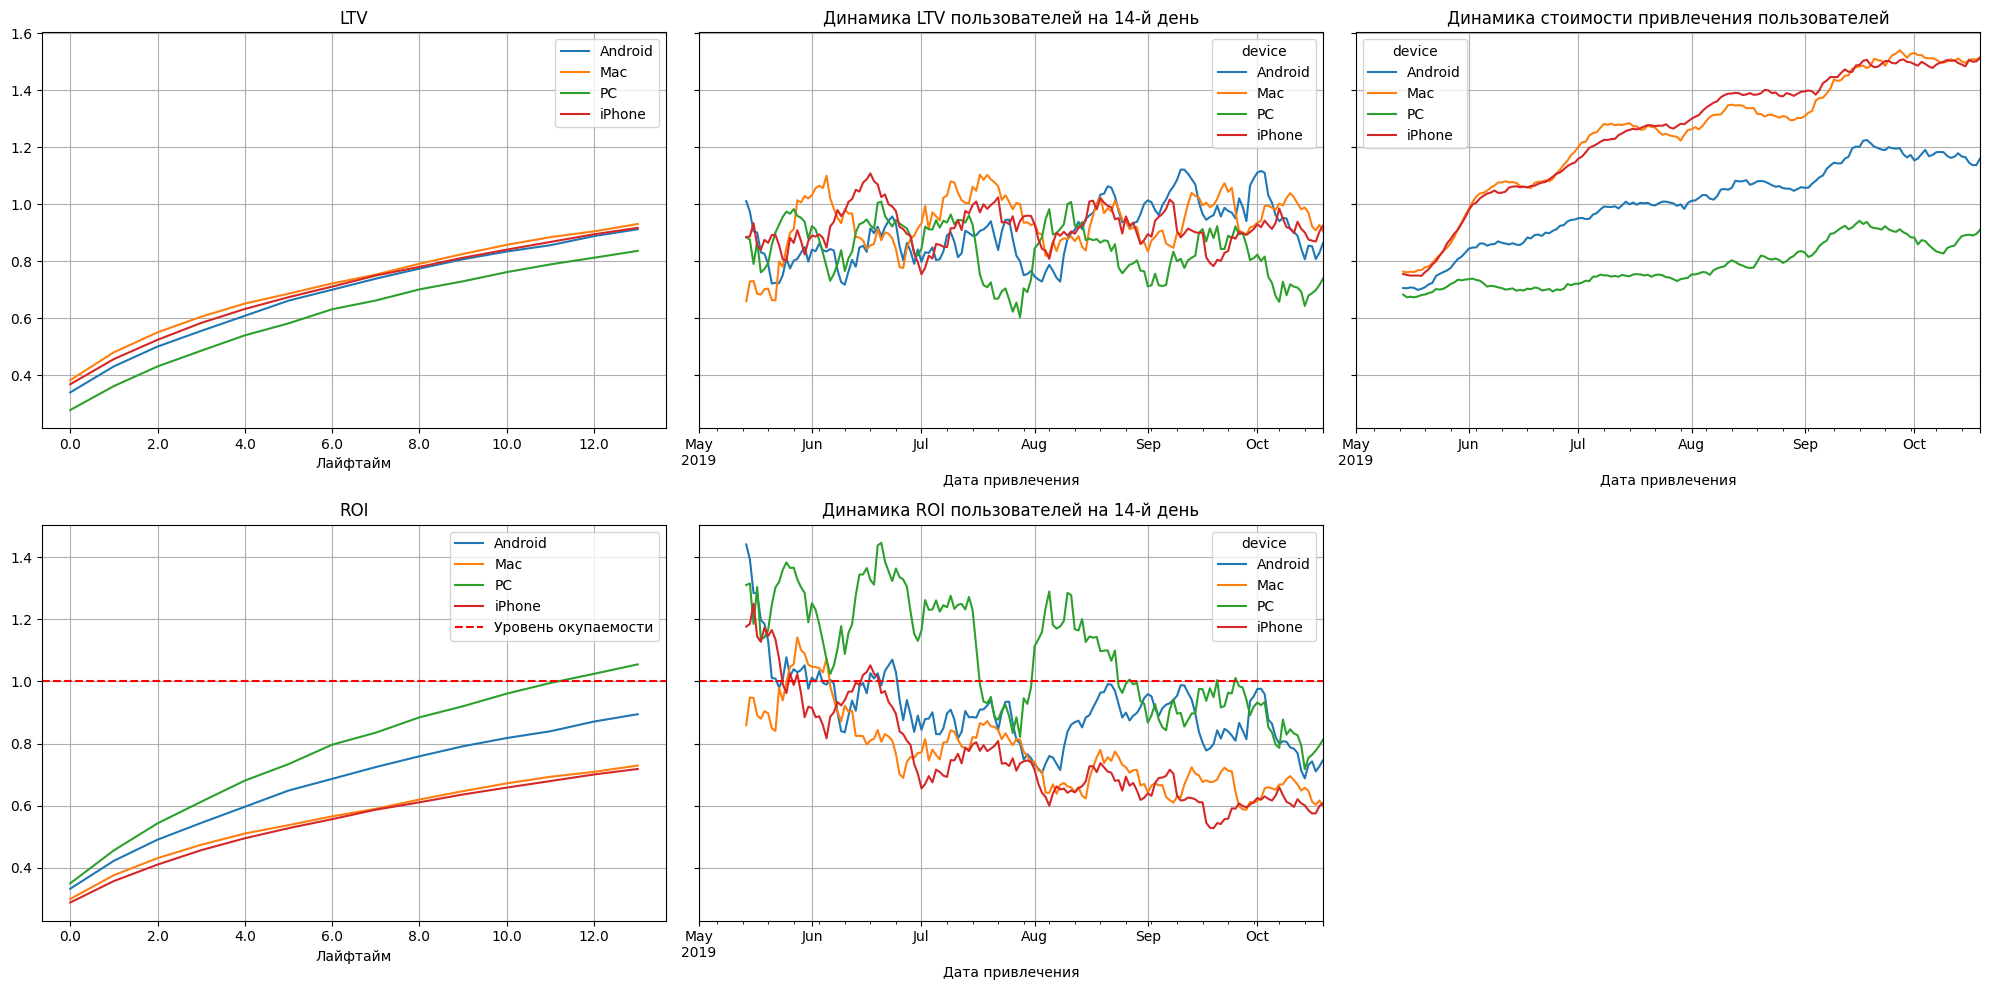

In [47]:
dimensions = ['device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_not_organic, orders, observation_date, horizon_days, dimensions=dimensions)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14)

Проблема окупаемости наблюдается для большинства устройств, поэтому причины, вероятно, связаны не с одной конкретной платформой, а с особенностями привлечения пользователей или качеством аудитории.

#### Окупаемость рекламы по странам

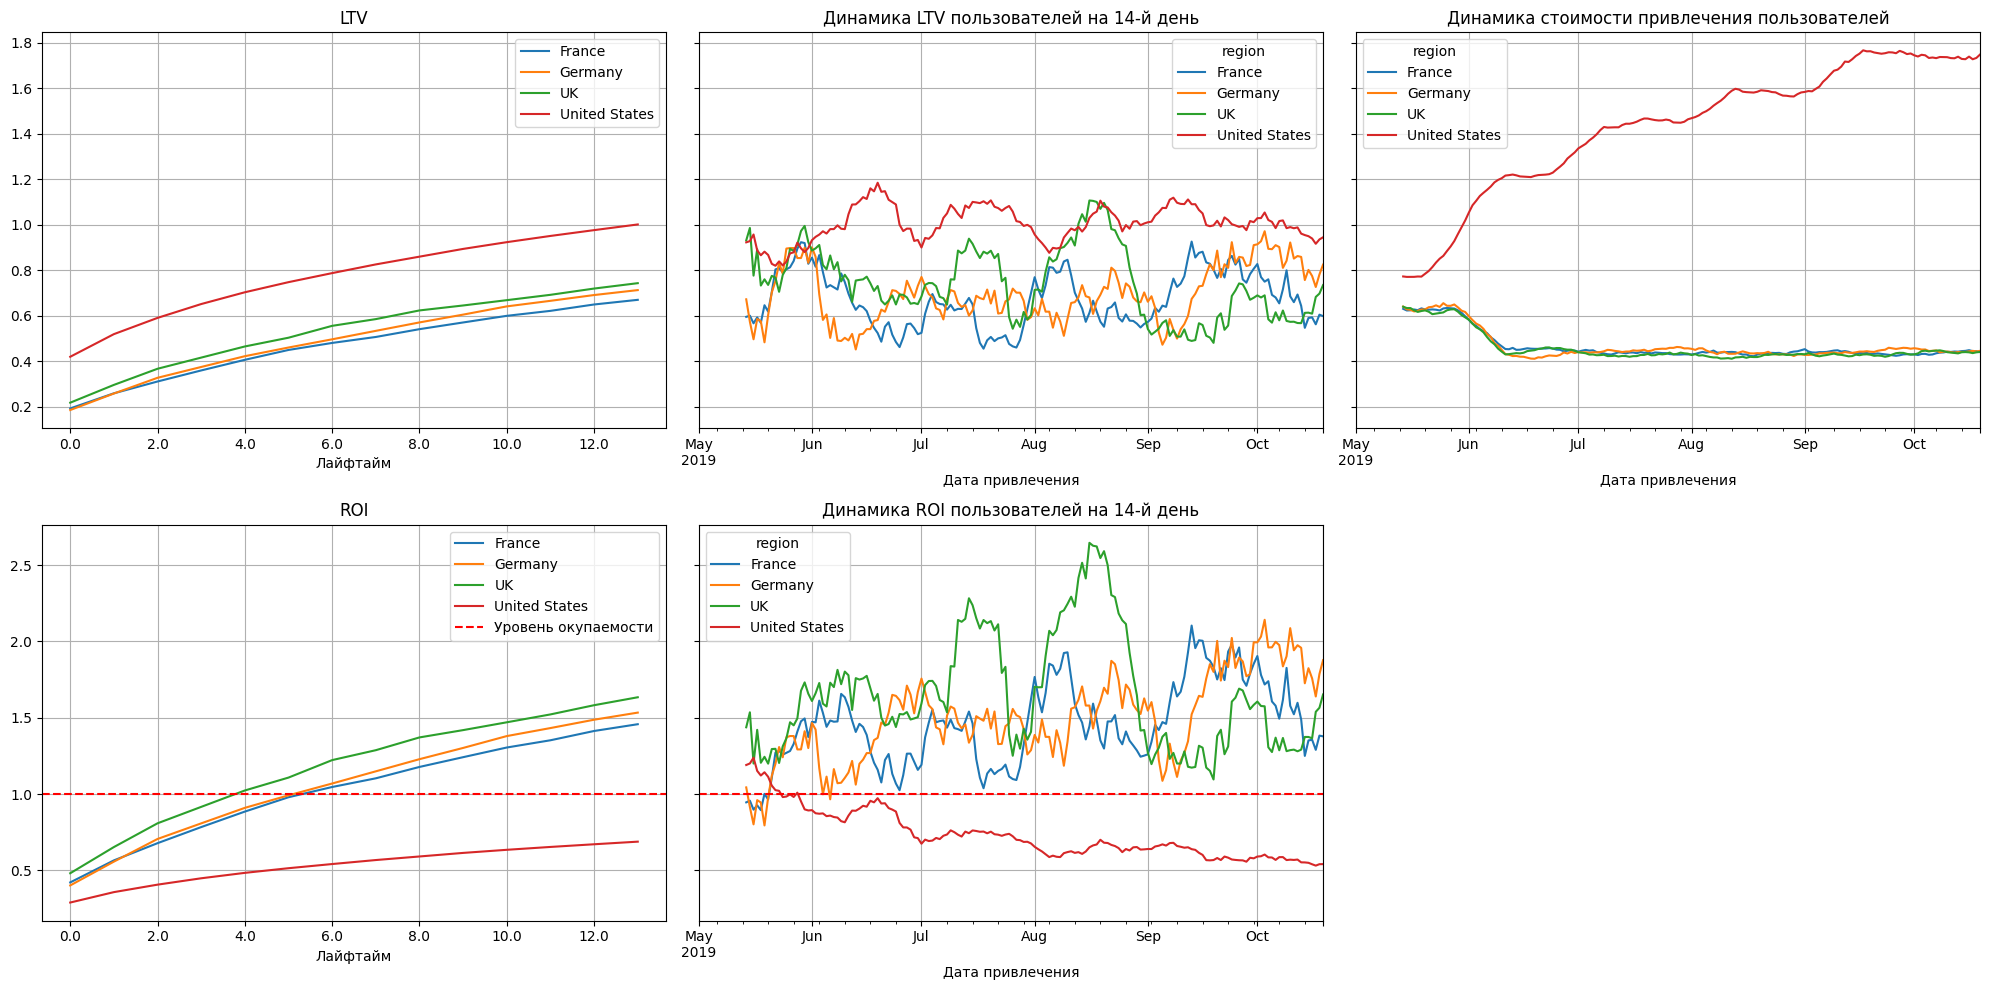

In [48]:
dimensions = ['region']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_not_organic, orders, observation_date, horizon_days, dimensions=dimensions)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14)

Посетители из Франции, Германии и Великобритании стабильно окупаются, их показатели ROI варьируются в пределах 140%-165%. Несмотря на то, что LTV пользователей из США выше европейских клиентов, уровень ROI у них на 14 день составляет всего лишь 65%. По стоимости привлечения США значительно лидируют, превышая CAC европейских стран на конец октября в 4.2 раза.


Несмотря на более высокий LTV пользователей из США, существенно более высокая стоимость их привлечения приводит к отрицательному влиянию на ROI. Таким образом, ключевая проблема рынка США заключается не в монетизации пользователей, а в чрезмерно высокой стоимости привлечения.

#### Окупаемость рекламы по каналам привлечения

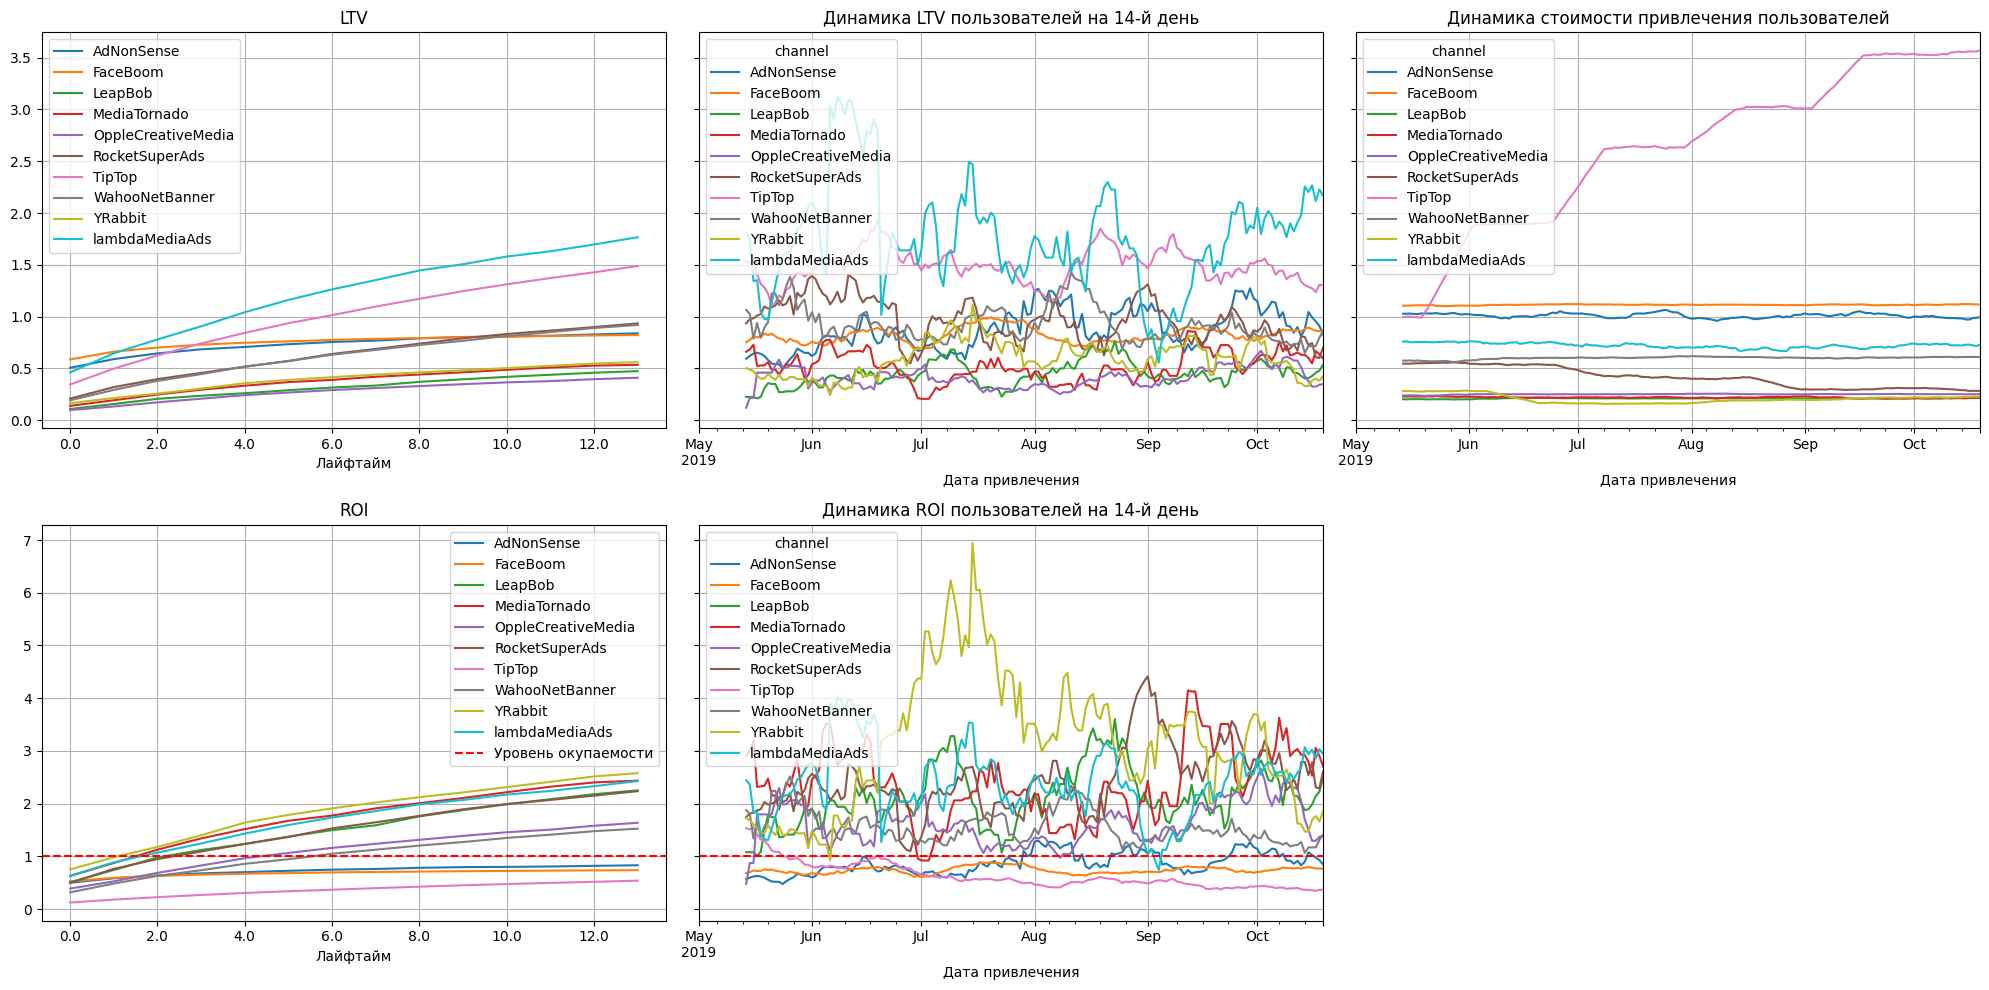

In [49]:
dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_not_organic, orders, observation_date, horizon_days, dimensions=dimensions)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14)

Из рекламных источников только три не достигают уровня окупаемости — это TipTop, AdNonSense и FaceBoom. Несмотря на большие вложения в канал TipTop, что подтверждается на графике динамики стоимости привлечения пользователей, данный источник не окупается. Самый высокий LTV относится к пользователям из рекламного канала lambdaMediaAds.

Каналы TipTop и FaceBoom одновременно являются крупнейшими источниками расходов и демонстрируют неудовлетворительную окупаемость, что делает их основными кандидатами для оптимизации рекламного бюджета.

# Выводы и рекомендации

Анализ показал, что реклама приложения Procrastinate Pro+ не окупается: показатель ROI к концу периода составляет около 81%, что ниже уровня окупаемости.

Основная причина связана с высокой стоимостью привлечения пользователей. Наибольшие расходы приходятся на каналы TipTop и FaceBoom, однако значительные маркетинговые затраты не компенсируются соответствующим ростом доходов. Особенно проблемным выглядит FaceBoom, который привлекает большое количество пользователей, но демонстрирует низкое удержание.

Наиболее серьёзное негативное влияние на окупаемость оказывает рынок США. Несмотря на высокий уровень монетизации пользователей, стоимость их привлечения значительно превышает показатели других стран. На европейском рынке проблемы окупаемости наблюдаются только у канала AdNonSense.

Рекомендации

* Сократить расходы на каналы TipTop, FaceBoom и AdNonSense либо пересмотреть стратегию закупки трафика.
* Увеличить внимание к более эффективным источникам привлечения: RocketSuperAds в США и lambdaMediaAds в Европе.
* Дополнительно исследовать причины низкого удержания пользователей по отдельным рекламным каналам.
* Перераспределить рекламный бюджет в пользу источников с более высоким ROI и стабильным LTV.
